# 14_损失函数-平方合页损失

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节咱们来聊聊平方合页损失\~

我们先从「合页损失（Hinge Loss）」讲起。

你可以把它想象成一个**合页（门轴）形状的损失函数**，最早是用在支持向量机（SVM）里的，用来判断分类是不是正确。

平方合页损失（Squared Hinge Loss）是它的“升级版” ，把原来的「合页损失」**再平方**，这样能让错误分类的惩罚更大。

### 怎么理解平方合页损失？

当你在做一个**二分类任务**，比如判断一张图是“猫”还是“不是猫”。

我们规定：

- 标签 $y$ 是 +1 表示是猫，-1 表示不是猫。
- 模型输出的结果（即预测分数）是 $f(x)$，越大表示越像是“猫”。

那么我们希望：

- 如果是猫（$y = +1$），预测分数也高（$f(x) \gg 0$）；
- 如果不是猫（$y = -1$），预测分数要很低（$f(x) \ll 0$）。

合页损失的思想是：

> **你预测得对，而且“信心”也够，那就没损失；否则就有惩罚。**

平方合页损失就是：

> **你预测错，或者“信心不够”，那我就“重重惩罚”你（因为平方啦）。**

### 核心逻辑

平方合页损失的数学公式如下：


$$
L(y, f(x)) = \left( \max\left(0, 1 - y \cdot f(x) \right) \right)^2
$$


其中：

- $y \in \{-1, +1\}$：真实标签；
- $f(x)$：模型对输入 $x$ 的预测分数（不是概率）；
- $y \cdot f(x)$：预测的“对错程度”；
- $1 - y \cdot f(x)$：越大说明预测越差；
- 外面的 $\max(0, \cdot)$：如果预测得很好（比如是 1.2），就没损失；
- 最后的平方：把错误的情况惩罚加重。

### 细化理解

我们逐步推导一下公式是怎么来的：

#### 第一步：为什么是 $y \cdot f(x)$？

我们希望：

- 如果 $y = +1$，那么 $f(x)$ 越大越好；
- 如果 $y = -1$，那么 $f(x)$ 越小越好。

所以我们用 $y \cdot f(x)$，它会：

- 正确分类时是正数；
- 错误分类时是负数；
- 越大表示分类越“有信心”。

#### 第二步：为什么是 $1 - y \cdot f(x)$？

我们希望分类“对的同时信心也足够”，而不是勉强正确。

所以我们设一个“信心门槛”：**希望** $y \cdot f(x) \geq 1$，表示“正确而且信心足够”。

那如果 $y \cdot f(x) \geq 1$：没损失，模型表现很好。

如果 $y \cdot f(x) < 1$：有损失，而且越偏离 1，惩罚越大。

所以我们构造了损失核心部分：


$$
\text{margin error} = 1 - y \cdot f(x)
$$


#### 第三步：为什么要 $\max(0, \cdot)$？

如果 $y \cdot f(x) \geq 1$，说明表现不错，那就不要惩罚，所以我们取：


$$
\max(0, 1 - y \cdot f(x))
$$


这就是**合页损失（Hinge Loss）**。

#### 第四步：为什么还要平方？

平方是为了两点：

1. **平滑**损失曲线，使得优化更稳定；
2. **惩罚加重**，对错误较大的情况（比如预测严重错误）损失增长更快。

所以得到了最终的平方合页损失：


$$
L(y, f(x)) = \left( \max(0, 1 - y \cdot f(x)) \right)^2
$$


### 图像理解

你可以想象这个函数的图像是这样的：

- 横轴是 $y \cdot f(x)$；
- 当 $y \cdot f(x) \geq 1$ 时，损失为 0；
- 当 $y \cdot f(x) < 1$ 时，损失是 $(1 - y \cdot f(x))^2$，就是个**抛物线形状**。

和普通合页损失的“折线”不同，平方合页损失更“圆滑”。

### 算法流程

以下是平方合页损失在训练中的典型使用流程：

#### 步骤 1：准备数据

- 样本 $x$、标签 $y \in \{-1, +1\}$

#### 步骤 2：前向传播

- 模型预测：计算 $f(x)$

#### 步骤 3：计算损失


$$
L = ( \max(0, 1 - y \cdot f(x)) )^2
$$


#### 步骤 4：计算梯度（用于更新模型）

- 如果 $y \cdot f(x) \geq 1$，梯度为 0（没损失）；
- 如果 $y \cdot f(x) < 1$，损失为 $(1 - y \cdot f(x))^2$，梯度较大。

#### 步骤 5：反向传播 + 参数更新

- 使用梯度下降等优化算法更新模型参数

#### 步骤 6：循环训练

- 对多个样本重复上面步骤，直到损失收敛。

## 案例说明

用一个简单的二维合成数据集，进行二分类任务，并用自定义的平方合页损失实现一个线性分类器。

Epoch 0: Loss=1.0000
Epoch 100: Loss=0.0550
Epoch 200: Loss=0.0512
Epoch 300: Loss=0.0505
Epoch 400: Loss=0.0504
Epoch 500: Loss=0.0503
Epoch 600: Loss=0.0503
Epoch 700: Loss=0.0503
Epoch 800: Loss=0.0503
Epoch 900: Loss=0.0503
Test Accuracy: 100.00%


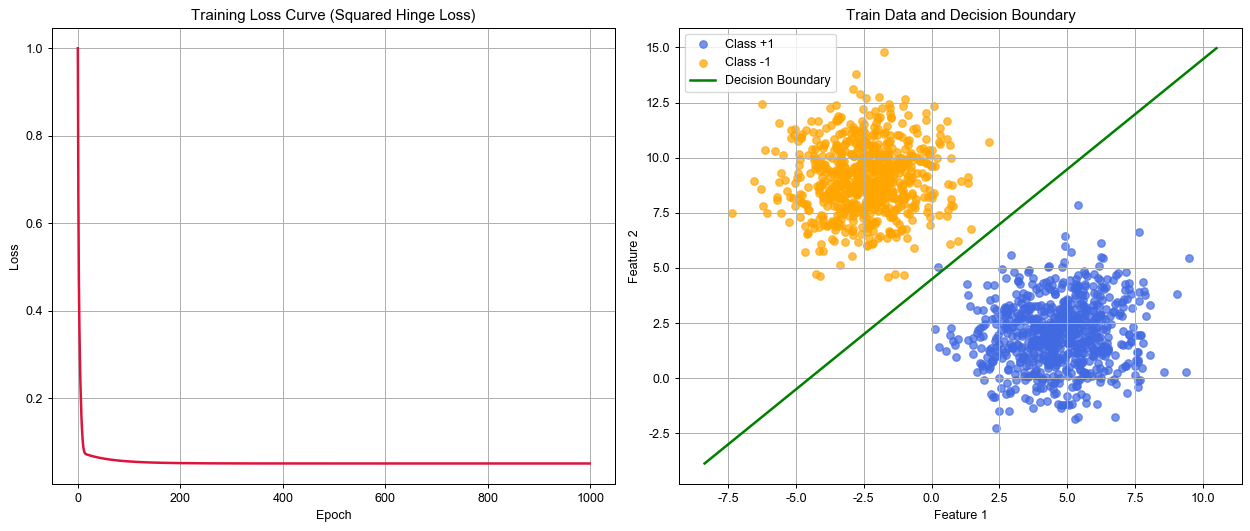

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# 1. 生成合成数据
X, y = make_blobs(n_samples=2000, centers=2, cluster_std=1.5, random_state=42)
y = 2 * (y - 0.5)  # 转换标签为{-1, +1}

# 2. 分割训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. 平方合页损失函数及其梯度
def squared_hinge_loss(w, X, y, C=1.0):
    """
    计算平方合页损失和梯度
    
    参数:
        w: 参数向量，包括权重和偏置 [w1, w2, b]
        X: 输入数据，形状 (N, 2)
        y: 标签 {-1, 1}
        C: 正则化参数
    
    返回:
        loss: 标量损失
        grad: 参数梯度，形状同w
    """
    N = X.shape[0]
    w_vec = w[:-1]
    b = w[-1]
    
    # 预测
    margins = 1 - y * (X.dot(w_vec) + b)
    losses = np.maximum(0, margins)
    loss = 0.5 * np.dot(w_vec, w_vec) + C * np.mean(losses ** 2)
    
    # 梯度计算
    indicator = (margins > 0).astype(float)
    grad_w = w_vec - 2 * C * np.mean((losses * indicator)[:, None] * y[:, None] * X, axis=0)
    grad_b = -2 * C * np.mean(losses * indicator * y)
    
    grad = np.append(grad_w, grad_b)
    return loss, grad

# 4. 梯度下降优化器
def gradient_descent(X, y, lr=0.01, epochs=1000, C=1.0):
    w = np.zeros(X.shape[1] + 1)  # 初始化参数
    losses = []
    
    for epoch in range(epochs):
        loss, grad = squared_hinge_loss(w, X, y, C)
        w -= lr * grad
        losses.append(loss)
        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss={loss:.4f}")
    return w, losses

# 5. 训练模型
w_opt, losses = gradient_descent(X_train, y_train, lr=0.1, epochs=1000, C=1.0)

# 6. 预测函数
def predict(X, w):
    return np.sign(X.dot(w[:-1]) + w[-1])

# 7. 测试集准确率
y_pred = predict(X_test, w_opt)
accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

# 8. 可视化结果
plt.figure(figsize=(14,6))

# 8.1 损失下降曲线
plt.subplot(1, 2, 1)
plt.plot(losses, color='crimson', linewidth=2)
plt.title('Training Loss Curve (Squared Hinge Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# 8.2 分类结果和决策边界
plt.subplot(1, 2, 2)
plt.scatter(X_train[y_train==1][:,0], X_train[y_train==1][:,1], color='royalblue', label='Class +1', alpha=0.7)
plt.scatter(X_train[y_train==-1][:,0], X_train[y_train==-1][:,1], color='orange', label='Class -1', alpha=0.7)

# 计算决策边界： w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b)/w2
x_vals = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_vals = -(w_opt[0] * x_vals + w_opt[2]) / w_opt[1]
plt.plot(x_vals, y_vals, color='green', linewidth=2, label='Decision Boundary')

plt.title('Train Data and Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

1. **生成数据**：使用 `make_blobs` 生成二维数据，分为两个类。转换标签为 $-1, +1$，符合 SVM 的习惯标签。
2. **划分训练集和测试集**：使用 `train_test_split` 保持训练和测试数据的独立性，测试比例30%。
3. **平方合页损失函数及梯度计算**：损失函数中包含两个部分：权重的L2正则化和平方合页损失的平均值。梯度部分，权重梯度由正则项和损失项组成，偏置梯度只来源于损失项。
4. **梯度下降优化**：初始化参数为零，迭代更新参数，每100步输出一次损失值以监控训练过程。
5. **模型训练**：以学习率0.1，迭代1000次，完成训练。
6. **预测函数**：使用符号函数输出预测类别。
7. **计算测试集准确率**：计算预测与真实标签匹配的比例。
8. **可视化**：左图为损失随训练轮数的变化，表现优化过程；右图展示训练数据的类别分布及最终的决策边界。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

## 模型分析

### 平方合页损失优缺点

**优点：**

- **平滑梯度**：平方合页损失相比标准合页损失在不满足间隔约束的样本上，损失的导数是连续且平滑的，这利于梯度下降的收敛速度和稳定性。
- **鲁棒性**：对离群点相对不那么敏感，因为大于间隔的样本不会增加损失；小于间隔的样本损失被平方放大，有助于模型更关注难分类的点。
- **凸优化问题**：依旧保持凸性质，可以利用成熟的优化算法保证收敛到全局最优。

**缺点：**

- **对异常点敏感**：相比标准合页损失，平方合页损失对距离边界很远的错误分类点惩罚更大（损失是平方），这可能导致模型对异常值过度调整。
- **计算量稍大**：平方操作使得梯度计算稍微复杂，尽管不明显，但相较于普通合页损失可能略慢。
- **非概率输出**：虽然与标准SVM相同，无法直接给出概率估计，需额外方法转换。

### 与相似算法对比

| 特性/算法 | 标准合页损失 (Hinge Loss) | 平方合页损失 (Squared Hinge Loss) | 对数损失（Log Loss, Logistic Regression） | 平方损失 (Squared Loss) |
|-|-|-|-|-|
| 损失形态 | $\max(0, 1 - y f(x))$ | $\max(0, 1 - y f(x))^2$ | $\log(1 + \exp(-y f(x)))$ | $(y - f(x))^2$ |
| 梯度连续性 | 不连续 | 连续且光滑 | 连续且光滑 | 连续且光滑 |
| 对离群点敏感度 | 中等 | 更敏感 | 更不敏感 | 非常敏感 |
| 输出解释 | 间隔最大化，非概率 | 间隔最大化，非概率 | 概率模型，输出概率 | 回归模型，非分类概率 |
| 优化难度 | 稍难，次梯度方法 | 较易，梯度法 | 较易，梯度法 | 很易 |
| 应用场景 | 经典SVM，间隔分类 | 需要平滑梯度的SVM | 概率分类及分类 | 回归问题或近似分类 |
| 对模型鲁棒性 | 较好 | 较好但对异常值更敏感 | 很好，容错性较高 | 较差 |

### 应用场景分析

- **何时优选平方合页损失？**

  - 你需要训练线性分类器并希望损失函数梯度更平滑，优化更稳定时。
  - 数据中噪声不大，但希望对边界附近难分类样本加重惩罚，增强模型的判别能力。
  - 你对模型训练的收敛速度和数值稳定性有一定需求。
- **何时考虑其他算法？**

  - 当你的数据中包含较多异常值，且不希望模型过度拟合异常点时，标准合页损失或对数损失更合适。
  - 需要概率输出时，逻辑回归（对数损失）优于平方合页损失。
  - 对于回归问题或非线性问题，平方损失或其他更复杂的损失函数（如Huber损失）更为适用。

## 总结

平方合页损失在SVM框架中是一种实用的变体，通过平方放大对边界违规点的惩罚，令梯度更平滑，优化更稳定。它是优化线性分类模型时的重要选择，特别是当你想提升训练稳定性和模型鲁棒性时。